# OCT Retinal Disease — Fused Grad-CAM with SSIM Robustness
**Pipeline:**
1. Imports, config, model & images
2. Predict classes for all 4 images
3. Define Standard Grad-CAM (last layer)
4. Define  Fused Grad-CAM (energy-weighted multi-layer)
5. Show Standard Grad-CAM heatmaps for all 4 images
6. Show Adaptive Fused Grad-CAM heatmaps for all 4 images
7. Add Gaussian noise (σ=0.1) to adaptive heatmaps — show result
8. SSIM comparison table: clean adaptive vs noisy adaptive

## 1. Imports, Configuration & Model Loading

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from skimage.metrics import structural_similarity
from google.colab import drive

# ── Mount Drive ────────────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_PATH  = '/content/drive/MyDrive/oct_retinal_model.keras'
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
IMG_SIZE    = (224, 224)
NOISE_STD   = 0.009   # σ for Gaussian noise perturbation

# Layer names: conv3_block4_out → 28×28
#              conv4_block6_out → 14×14
#              conv5_block3_out →  7×7  (last conv layer — also used for Standard Grad-CAM)
LAYER_NAMES = ['conv3_block4_out', 'conv4_block6_out', 'conv5_block3_out']
LAST_LAYER  = LAYER_NAMES[-1]  # conv5_block3_out

# ── 4 Target Images ───────────────────────────────────────────────────────────
IMAGES = {
    'CNV':    '/content/drive/MyDrive/Retinal_Oct_Keras_Model/CNV-1894770-2.jpeg',
    'DME':    '/content/drive/MyDrive/Retinal_Oct_Keras_Model/DME-8000885-1.jpeg',
    'DRUSEN': '/content/drive/MyDrive/Retinal_Oct_Keras_Model/DRUSEN-9624303-2.jpeg',
    'NORMAL': '/content/drive/MyDrive/Retinal_Oct_Keras_Model/NORMAL-76914-1.jpeg',
}

# ── Load model ─────────────────────────────────────────────────────────────────
model      = tf.keras.models.load_model(MODEL_PATH)
base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))

print(f"Model loaded   : {MODEL_PATH}")
print(f"Base model     : {base_model.name}")
print(f"GPU available  : {len(tf.config.list_physical_devices('GPU')) > 0}")

# ── Verify all 4 image paths exist ────────────────────────────────────────────
for cls, path in IMAGES.items():
    status = "✓ Found" if os.path.exists(path) else "✗ MISSING"
    print(f"  {cls:8s}: {status}  ({path})")

Mounted at /content/drive
Model loaded   : /content/drive/MyDrive/oct_retinal_model.keras
Base model     : resnet50
GPU available  : True
  CNV     : ✓ Found  (/content/drive/MyDrive/Retinal_Oct_Keras_Model/CNV-1894770-2.jpeg)
  DME     : ✓ Found  (/content/drive/MyDrive/Retinal_Oct_Keras_Model/DME-8000885-1.jpeg)
  DRUSEN  : ✓ Found  (/content/drive/MyDrive/Retinal_Oct_Keras_Model/DRUSEN-9624303-2.jpeg)
  NORMAL  : ✓ Found  (/content/drive/MyDrive/Retinal_Oct_Keras_Model/NORMAL-76914-1.jpeg)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 40 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 2. Preprocessing & Prediction for All 4 Images

In [ ]:
def load_image(path):
    """Load, convert to RGB, resize, and return:
       img_pp   : (1, 224, 224, 3) float32 — ResNet-normalised for model input
       img_disp : (224, 224, 3)   float32  — [0,1] range for plotting
    """
    img_bgr  = cv2.imread(str(path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res  = cv2.resize(img_rgb, (IMG_SIZE[1], IMG_SIZE[0]))
    img_disp = img_res.astype(np.float32) / 255.0
    img_pp   = preprocess_input(img_res.astype(np.float32))   # ResNet mean-subtraction
    return np.expand_dims(img_pp, axis=0), img_disp

In [ ]:
# ── Run inference on all 4 images ─────────────────────────────────────────────
print(f"{'Class':8s}  {'Predicted':8s}  {'Confidence':>12s}  {'Correct?':8s}")
print("-" * 50)

data = {}   # stores preprocessed arrays + prediction results keyed by true class

for cls, path in IMAGES.items():
    img_pp, img_disp = load_image(path)
    preds            = model.predict(img_pp, verbose=0)[0]
    pred_idx         = int(np.argmax(preds))
    pred_label       = CLASS_NAMES[pred_idx]
    confidence       = float(preds[pred_idx])
    correct          = "✓" if pred_label == cls else "✗"

    data[cls] = {
        'img_pp'   : img_pp,
        'img_disp' : img_disp,
        'pred_idx' : pred_idx,
        'pred_label': pred_label,
        'confidence': confidence,
        'preds'    : preds,
    }
    print(f"{cls:8s}  {pred_label:8s}  {confidence:>12.4%}  {correct}")

Class     Predicted    Confidence  Correct?
--------------------------------------------------
CNV       CNV           99.8710%  ✓
DME       DME           97.7334%  ✓
DRUSEN    DRUSEN        89.5524%  ✓
NORMAL    NORMAL        99.5091%  ✓


## 3. Grad-CAM Function Definitions

### Standard Grad-CAM
Uses a **single layer** (the last convolutional layer `conv5_block3_out`).

$$L^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right), \quad \alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}}$$

### Adaptive Fused Grad-CAM
Combines heatmaps from **three layers** using **feature-energy weights**:

$$E_l = \frac{1}{CHW}\sum|A^{(c,l)}|, \quad w_l = \frac{E_l}{\sum_{l'} E_{l'}}, \quad H_f = \sum_l w_l \hat{H}_l$$

In [ ]:
# ── Shared utility: normalise & resize a raw CAM ──────────────────────────────
def _normalise_resize(cam):
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cv2.resize(cam, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_LINEAR)


# ── Overlay heatmap on image ──────────────────────────────────────────────────
def overlay(img_disp, heatmap, alpha=0.5):
    """Blend a [0,1] heatmap over a [0,1] RGB image. Returns uint8 RGB."""
    h_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    h_rgb   = cv2.cvtColor(h_color, cv2.COLOR_BGR2RGB)
    img_u8  = (img_disp * 255).astype(np.uint8)
    return cv2.addWeighted(img_u8, 1 - alpha, h_rgb, alpha, 0)


# ── Standard Grad-CAM (single layer) ─────────────────────────────────────────
def standard_gradcam(img_pp, pred_idx, layer_name=LAST_LAYER):
    """
    Compute Grad-CAM using one convolutional layer (default: last layer).
    Returns a normalised (224, 224) heatmap in [0, 1].
    """
    # Sub-model: base_model input → [target_layer output, base_model output]
    inner_model = tf.keras.Model(
        inputs  = base_model.inputs,
        outputs = [base_model.get_layer(layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        img_t          = tf.cast(img_pp, tf.float32)
        conv_out, base_out = inner_model(img_t)
        tape.watch(conv_out)

        # Pass base output through top-level head layers
        x = base_out
        base_found = False
        for layer in model.layers:
            if layer == base_model:
                base_found = True
                continue
            if base_found:
                x = layer(x)

        loss = x[:, pred_idx]

    grads        = tape.gradient(loss, conv_out)
    # Fallback: direct functional path if gradients are None
    if grads is None:
        gm = tf.keras.Model(inputs=model.inputs,
                            outputs=[base_model.get_layer(layer_name).output, model.output])
        with tf.GradientTape() as tape2:
            conv_out, preds = gm(tf.cast(img_pp, tf.float32))
            loss = preds[:, pred_idx]
        grads = tape2.gradient(loss, conv_out)

    weights  = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    cam_raw  = np.dot(conv_out[0].numpy(), weights)
    return _normalise_resize(cam_raw)


# ── Adaptive Fused Grad-CAM (multi-layer, energy-weighted) ───────────────────
def adaptive_gradcam(img_pp, pred_idx, layer_names=LAYER_NAMES):
    """
    Compute Grad-CAM for each layer in layer_names, derive fusion weights from
    activation energy, and return the weighted fused heatmap in [0, 1].
    Also returns the per-layer weights dict for reporting.
    """
    cams     = []
    energies = []

    for ln in layer_names:
        inner_model = tf.keras.Model(
            inputs  = base_model.inputs,
            outputs = [base_model.get_layer(ln).output, base_model.output]
        )
        with tf.GradientTape() as tape:
            img_t              = tf.cast(img_pp, tf.float32)
            conv_out, base_out = inner_model(img_t)
            tape.watch(conv_out)
            x = base_out
            base_found = False
            for layer in model.layers:
                if layer == base_model:
                    base_found = True; continue
                if base_found: x = layer(x)
            loss = x[:, pred_idx]

        grads = tape.gradient(loss, conv_out)
        if grads is None:
            gm = tf.keras.Model(inputs=model.inputs,
                                outputs=[base_model.get_layer(ln).output, model.output])
            with tf.GradientTape() as t2:
                conv_out, preds = gm(tf.cast(img_pp, tf.float32))
                loss = preds[:, pred_idx]
            grads    = t2.gradient(loss, conv_out)

        w_k   = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
        fmap  = conv_out[0].numpy()                     # (H', W', C)
        cam   = _normalise_resize(np.dot(fmap, w_k))    # (224, 224)

        cams.append(cam)
        energies.append(float(np.mean(np.abs(fmap))))   # E_l

    # Normalise energies → fusion weights
    total   = sum(energies) + 1e-8
    weights = [e / total for e in energies]
    weights_dict = {ln: round(w, 4) for ln, w in zip(layer_names, weights)}

    # Weighted sum → final fused heatmap
    Hf = sum(w * c for w, c in zip(weights, cams)).astype(np.float32)
    Hf = (Hf - Hf.min()) / (Hf.max() - Hf.min() + 1e-8)  # normalise to [0,1]
    return Hf, weights_dict


print("standard_gradcam() and adaptive_gradcam() defined.")

standard_gradcam() and adaptive_gradcam() defined.


## 4. Compute All Heatmaps for the 4 Images

In [ ]:
# For each image compute:
#   std_cam : Standard Grad-CAM (last layer only)
#   Hf      : Adaptive Fused Grad-CAM (clean)
#   Hn      : Adaptive Fused Grad-CAM + Gaussian noise (σ=0.1)

for cls in CLASS_NAMES:
    d = data[cls]

    # Standard Grad-CAM
    d['std_cam'] = standard_gradcam(d['img_pp'], d['pred_idx'])

    # Adaptive Fused Grad-CAM
    d['Hf'], d['weights'] = adaptive_gradcam(d['img_pp'], d['pred_idx'])

    # Noisy Adaptive Heatmap
    noise      = np.random.normal(0, NOISE_STD, d['Hf'].shape).astype(np.float32)
    d['Hn']    = np.clip(d['Hf'] + noise, 0.0, 1.0)

    # SSIM
    d['ssim']  = float(structural_similarity(d['Hf'], d['Hn'], data_range=1.0))

    print(f"{cls:8s} | pred: {d['pred_label']:8s} ({d['confidence']:.2%}) | "
          f"weights: {d['weights']} | SSIM: {d['ssim']:.6f}")

CNV      | pred: CNV      (99.87%) | weights: {'conv3_block4_out': 0.4345, 'conv4_block6_out': 0.3178, 'conv5_block3_out': 0.2477} | SSIM: 0.945932
DME      | pred: DME      (97.73%) | weights: {'conv3_block4_out': 0.413, 'conv4_block6_out': 0.3011, 'conv5_block3_out': 0.2859} | SSIM: 0.944497
DRUSEN   | pred: DRUSEN   (89.55%) | weights: {'conv3_block4_out': 0.4403, 'conv4_block6_out': 0.3162, 'conv5_block3_out': 0.2435} | SSIM: 0.954820
NORMAL   | pred: NORMAL   (99.51%) | weights: {'conv3_block4_out': 0.4818, 'conv4_block6_out': 0.3281, 'conv5_block3_out': 0.1901} | SSIM: 0.956935


## 5. Standard Grad-CAM Heatmaps (Last Layer: `conv5_block3_out`)

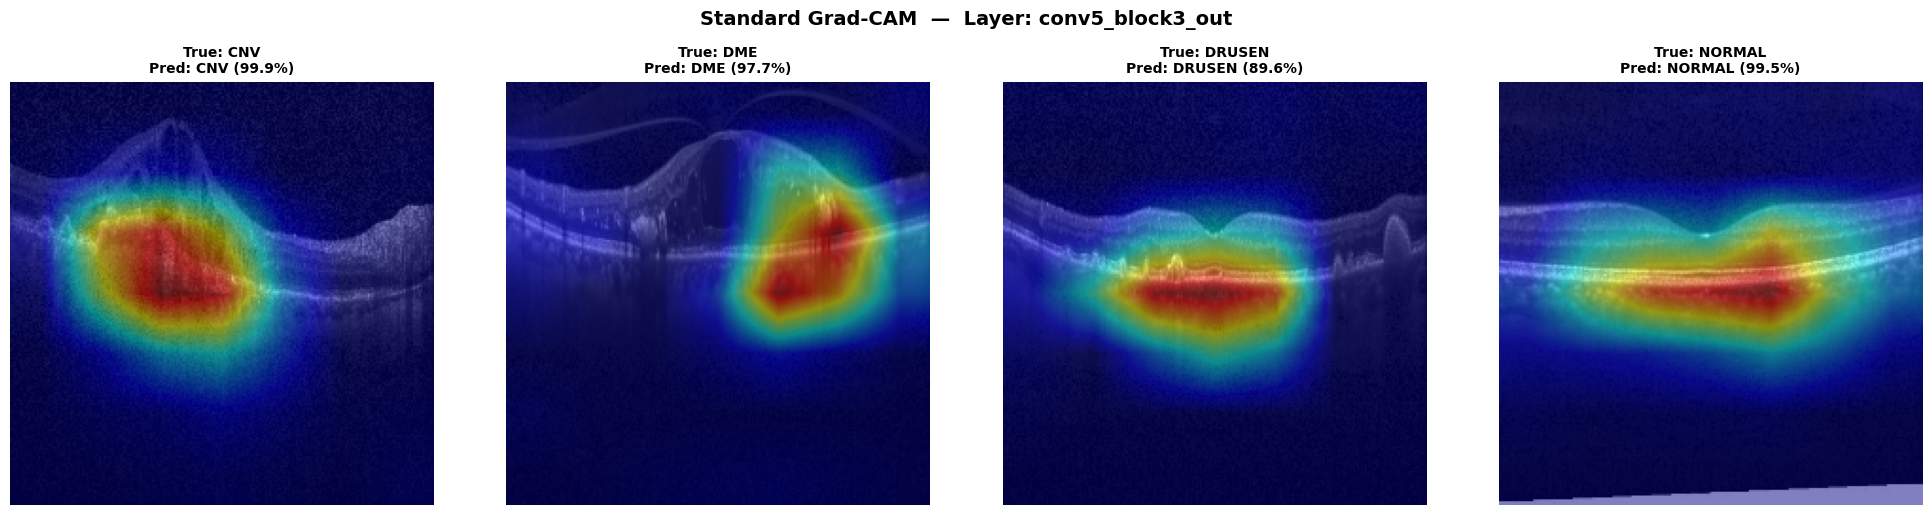

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, cls in enumerate(CLASS_NAMES):
    d = data[cls]
    axes[i].imshow(overlay(d['img_disp'], d['std_cam']))
    axes[i].set_title(f"True: {cls}\nPred: {d['pred_label']} ({d['confidence']:.1%})",
                      fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Standard Grad-CAM  —  Layer: {LAST_LAYER}",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Fused Grad-CAM Heatmaps (Multi-Layer, No Noise)

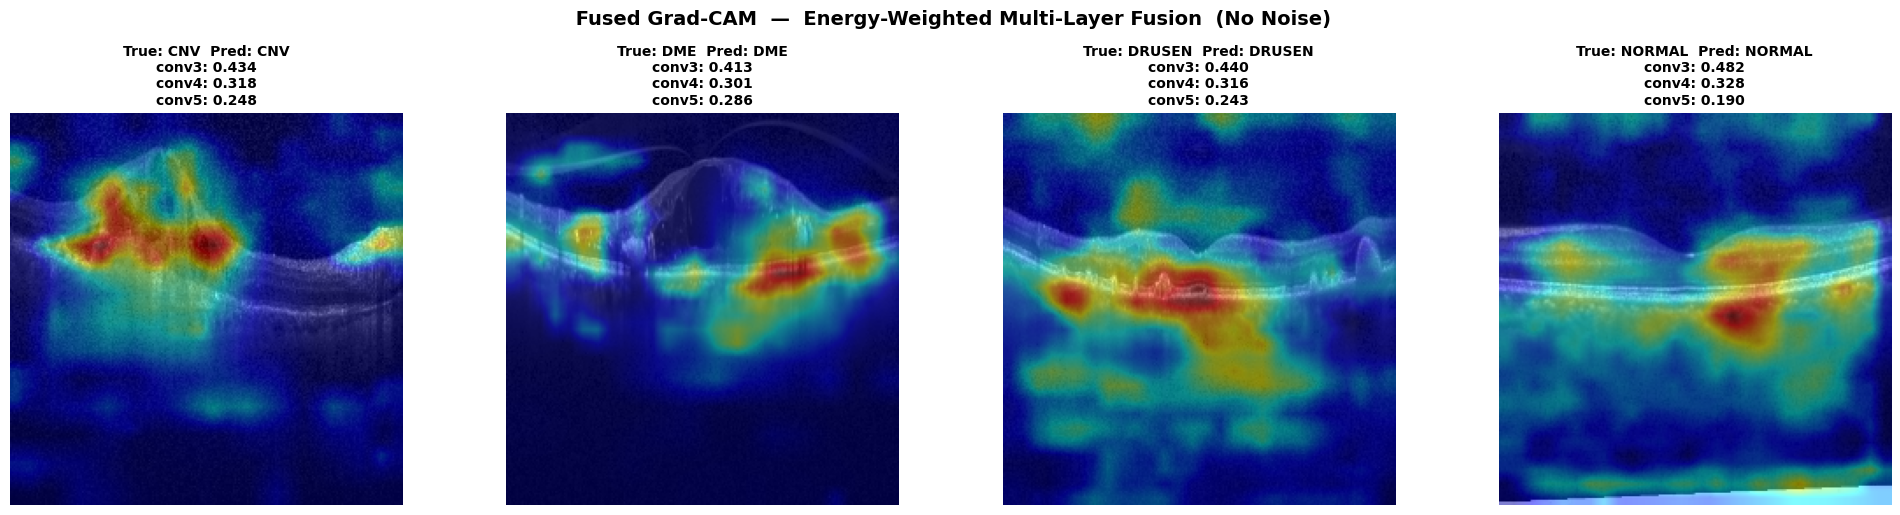

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, cls in enumerate(CLASS_NAMES):
    d = data[cls]
    # Build a label showing fusion weights
    w_str = "\n".join([f"{ln.split('_')[0]}: {v:.3f}" for ln, v in d['weights'].items()])
    axes[i].imshow(overlay(d['img_disp'], d['Hf']))
    axes[i].set_title(f"True: {cls}  Pred: {d['pred_label']}\n{w_str}", fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(" Fused Grad-CAM  —  Energy-Weighted Multi-Layer Fusion  (No Noise)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Noisy Fused Grad-CAM Heatmaps (σ = 0.1)

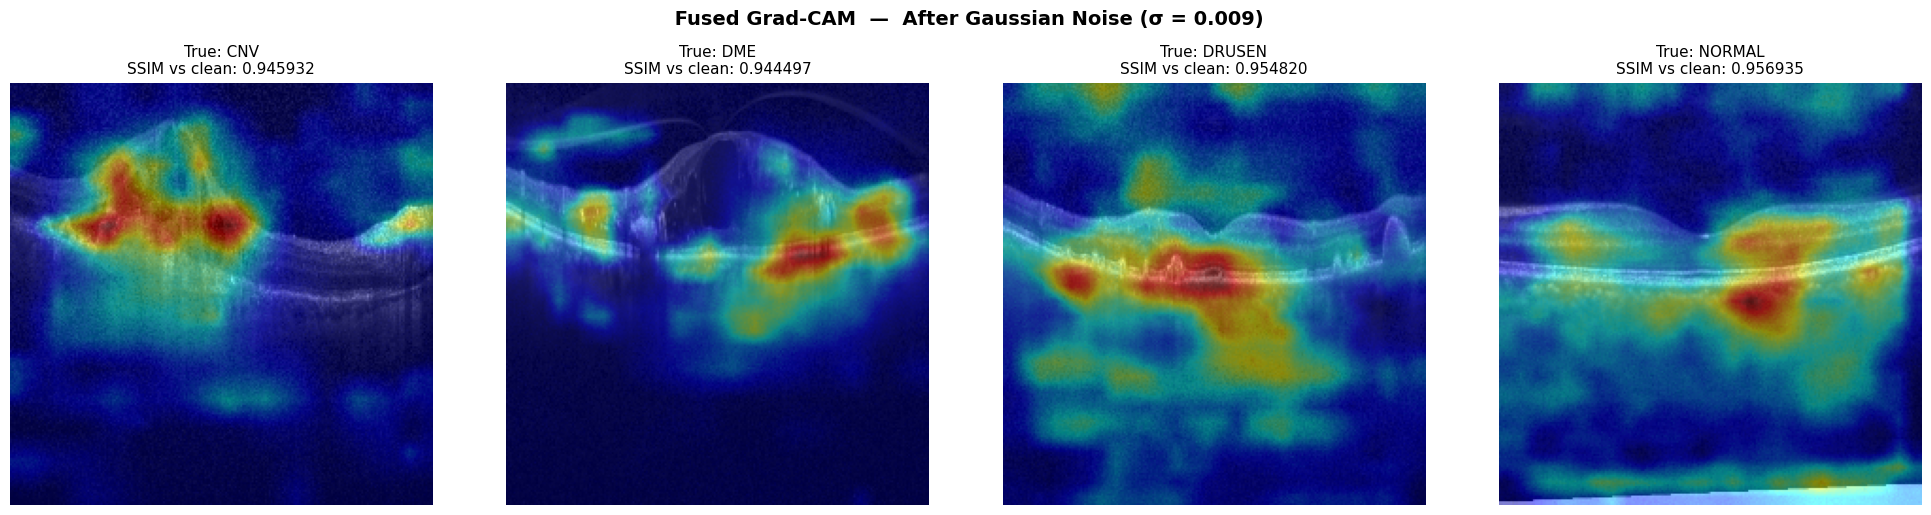

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, cls in enumerate(CLASS_NAMES):
    d = data[cls]
    axes[i].imshow(overlay(d['img_disp'], d['Hn']))
    axes[i].set_title(f"True: {cls}\nSSIM vs clean: {d['ssim']:.6f}", fontsize=11)
    axes[i].axis('off')

plt.suptitle(f" Fused Grad-CAM  —  After Gaussian Noise (σ = {NOISE_STD})",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Side-by-Side: Clean Fused vs Noisy Adaptive

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

col_titles = ['Original OCT', ' Fused CAM(Clean)', f'Fused CAM (Noisy σ={NOISE_STD})', 'Difference  |Hf − Hn|']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

for row, cls in enumerate(CLASS_NAMES):
    d    = data[cls]
    diff = np.abs(d['Hf'] - d['Hn'])

    axes[row][0].imshow(d['img_disp'])
    axes[row][0].set_ylabel(f"{cls}\nPred: {d['pred_label']}\n({d['confidence']:.1%})",
                            fontsize=10, rotation=0, labelpad=80, va='center')

    axes[row][1].imshow(overlay(d['img_disp'], d['Hf']))

    axes[row][2].imshow(overlay(d['img_disp'], d['Hn']))
    axes[row][2].set_xlabel(f"SSIM = {d['ssim']:.6f}", fontsize=10)

    im = axes[row][3].imshow(diff, cmap='hot', vmin=0, vmax=diff.max() + 1e-6)
    plt.colorbar(im, ax=axes[row][3], fraction=0.046, pad=0.04)

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle("Clean vs Noisy  Fused Grad-CAM — All 4 Classes",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. SSIM Robustness Results Table

In [ ]:
rows = []
for cls in CLASS_NAMES:
    d = data[cls]

    # Calculate noisy standard Grad-CAM and its SSIM if not already present
    # This ensures it's computed only once or if the cell is run out of order
    if 'std_ssim' not in d:
        # Generate noisy version of standard Grad-CAM
        noise_std_cam = np.random.normal(0, NOISE_STD, d['std_cam'].shape).astype(np.float32)
        std_cam_noisy = np.clip(d['std_cam'] + noise_std_cam, 0.0, 1.0)

        # Calculate SSIM for standard Grad-CAM
        d['std_ssim'] = float(structural_similarity(d['std_cam'], std_cam_noisy, data_range=1.0))
        # Store the noisy version for potential future visualization, if needed
        d['std_cam_noisy'] = std_cam_noisy

    rows.append({
        'True Class'           : cls,
        'Predicted'            : d['pred_label'],
        'Confidence'           : f"{d['confidence']:.4%}",
        'Noise σ'              : NOISE_STD,
        'SSIM (Adaptive)'      : round(d['ssim'], 6),
        'Stability (Adaptive)' : 'High' if d['ssim'] >= 0.90 else ('Medium' if d['ssim'] >= 0.75 else 'Low'),
        'SSIM (Standard)'      : round(d['std_ssim'], 6),
        'Stability (Standard)' : 'High' if d['std_ssim'] >= 0.90 else ('Medium' if d['std_ssim'] >= 0.75 else 'Low'),
    })

ssim_df = pd.DataFrame(rows)

# Pretty-print
display(ssim_df.style
    .background_gradient(cmap='RdYlGn', subset=['SSIM (Adaptive)', 'SSIM (Standard)'])
    .set_properties(**{'text-align': 'center'})
    .set_caption(f"SSIM Robustness Comparison: Clean vs Noisy (σ={NOISE_STD})")
)

print(f"\n--- Adaptive Fused Grad-CAM ---")
print(f"Mean SSIM : {ssim_df['SSIM (Adaptive)'].mean():.6f}")
print(f"Min  SSIM : {ssim_df['SSIM (Adaptive)'].min():.6f}")
print(f"Max  SSIM : {ssim_df['SSIM (Adaptive)'].max():.6f}")

print(f"\n--- Standard Grad-CAM ---")
print(f"Mean SSIM : {ssim_df['SSIM (Standard)'].mean():.6f}")
print(f"Min  SSIM : {ssim_df['SSIM (Standard)'].min():.6f}")
print(f"Max  SSIM : {ssim_df['SSIM (Standard)'].max():.6f}")

print("\nInterpretation: SSIM closer to 1.0 = explanation is structurally stable under noise.")

,True Class,Predicted,Confidence,Noise σ,SSIM (Adaptive),Stability (Adaptive),SSIM (Standard),Stability (Standard)
0,CNV,CNV,99.8710%,0.009000,0.945932,High,0.928407,High
1,DME,DME,97.7334%,0.009000,0.944497,High,0.931644,High
2,DRUSEN,DRUSEN,89.5524%,0.009000,0.954820,High,0.921329,High
3,NORMAL,NORMAL,99.5091%,0.009000,0.956935,High,0.933862,High



--- Adaptive Fused Grad-CAM ---
Mean SSIM : 0.950546
Min  SSIM : 0.944497
Max  SSIM : 0.956935

--- Standard Grad-CAM ---
Mean SSIM : 0.928810
Min  SSIM : 0.921329
Max  SSIM : 0.933862

Interpretation: SSIM closer to 1.0 = explanation is structurally stable under noise.


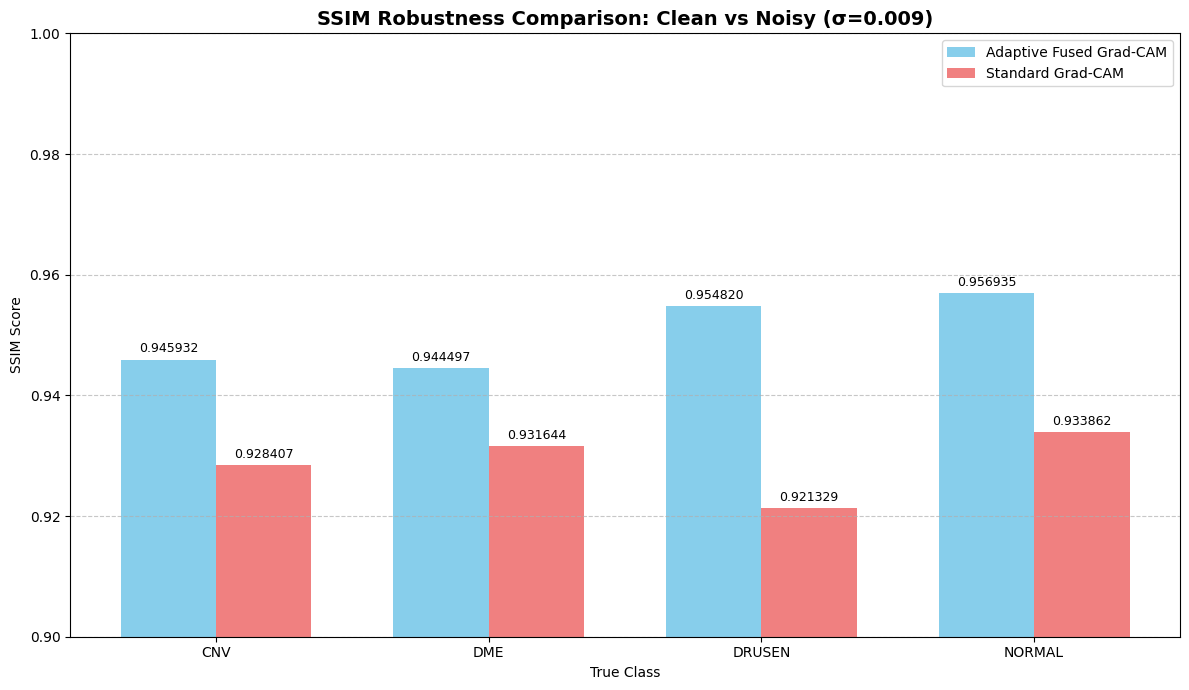

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
classes = ssim_df['True Class']
adaptive_ssim_scores = ssim_df['SSIM (Adaptive)']
standard_ssim_scores = ssim_df['SSIM (Standard)']

# Set up the bar chart positions and width
x = np.arange(len(classes))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

# Create grouped bar charts
rects1 = ax.bar(x - width/2, adaptive_ssim_scores, width, label='Adaptive Fused Grad-CAM', color='skyblue')
rects2 = ax.bar(x + width/2, standard_ssim_scores, width, label='Standard Grad-CAM', color='lightcoral')

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('True Class')
ax.set_ylabel('SSIM Score')
ax.set_title(f'SSIM Robustness Comparison: Clean vs Noisy (σ={NOISE_STD})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0.90, 1.0) # Adjust y-axis limits to highlight differences more clearly
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# Function to add SSIM scores on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.6f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()